# Grover Algorithm
## Phabel Antonio López Delgado <phabel2001@gmail.com>

In [1]:
# Instalar Librerias
!pip install -q qiskit
!pip install -q qiskit-aer
!pip install -q qiskit[visualization]
!pip install -q pylatexenc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.0/109.0 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 108.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 8.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [68]:
# Import Libraries
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import Aer
import numpy as np
import matplotlib.pyplot as plt

In [69]:
# Data: set of numbers and target sum
numbers = [1, 2, 3]
# Find subset(s) summing to this value
target_sum = 3
# Number of QBits
n_qubits = len(numbers)

# Quantum and Classical Registers
# Subset selector qubits
qr = QuantumRegister(n_qubits, 'q')
# For measurement
cr = ClassicalRegister(n_qubits, 'c')

# Set Quantum Circuit
qc = QuantumCircuit(qr, cr)

# 1. Initialize in superposition over all subsets
qc.h(qr)

# 2. Construct the oracle that flips phase for states where sum == target_sum
def construct_oracle(n_qubits, numbers, target_sum):
    oracle = QuantumCircuit(n_qubits)
    # Loop over all basis states (possible subsets)
    for i in range(2**n_qubits):
        binary_state = format(i, f'0{n_qubits}b')
        subset_elements = [numbers[j] for j, bit in enumerate(binary_state) if bit == '1']
        if sum(subset_elements) == target_sum:
            # Phase flip for this basis state
            controls = []
            for j, bit in enumerate(binary_state):
                if bit == '1':
                    controls.append(qr[j])
                else:
                    # To control on |0>, flip qubit
                    oracle.x(qr[j])
                    controls.append(qr[j])
            # Multi-controlled Z gate
            oracle.h(n_qubits - 1)
            oracle.mcx(controls[:-1], qr[-1])
            oracle.h(n_qubits - 1)
            # Undo X gates
            for j, bit in enumerate(binary_state):
                if bit == '0':
                    oracle.x(qr[j])
    return oracle

# Oracle
oracle = construct_oracle(n_qubits, numbers, target_sum)

# 3. Define Quantum Fourier Transform (QFT)
def qft(n):
    qc_qft = QuantumCircuit(n)
    for qubit in range(n):
        qc_qft.h(qubit)
        for j in range(qubit + 1, n):
            qc_qft.cp(np.pi / 2**(j - qubit), j, qubit)
    return qc_qft

# 4. Inverse QFT
def inverse_qft(n):
    return qft(n).inverse()

# 5. Diffusion operator (Grover's diffusion / inversion about the mean)
def diffusion_operator(n):
    diff = QuantumCircuit(n)
    diff.compose(qft(n), inplace=True)
    # Inversion about |0⟩
    for qubit in range(n):
        diff.h(qubit)
        diff.x(qubit)
    # Multi-controlled Z
    diff.h(n - 1)
    controls = list(range(n - 1))
    diff.mcx(controls, n - 1)
    diff.h(n - 1)
    # Undo inversion
    for qubit in range(n):
        diff.x(qubit)
        diff.h(qubit)
    diff.compose(inverse_qft(n), inplace=True)
    return diff

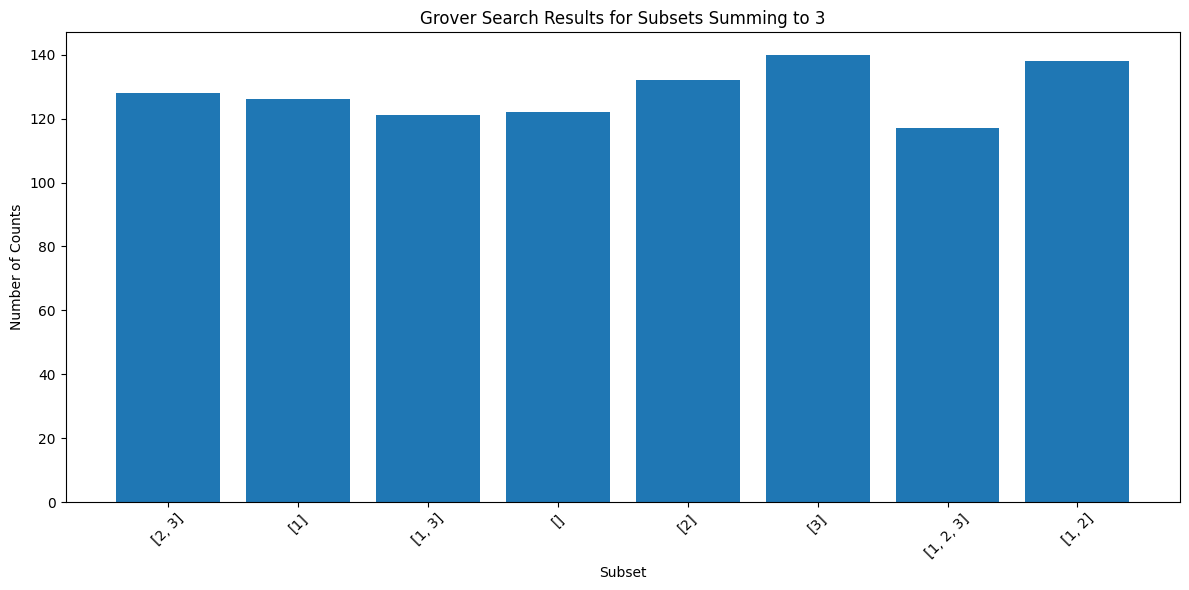

Measurement results (bitstring: counts) for 3:
110 -> subset: [2, 3], sum: 5, counts: 128
001 -> subset: [1], sum: 1, counts: 126
101 -> subset: [1, 3], sum: 4, counts: 121
000 -> subset: [], sum: 0, counts: 122
010 -> subset: [2], sum: 2, counts: 132
100 -> subset: [3], sum: 3, counts: 140
111 -> subset: [1, 2, 3], sum: 6, counts: 117
011 -> subset: [1, 2], sum: 3, counts: 138


In [84]:
# 6. Calculate number of Grover iterations (roughly)
num_iterations = int(np.floor(np.pi/4 * np.sqrt(2**n_qubits)))

# 7. Perform Grover iterations
for _ in range(num_iterations):
    qc.compose(oracle, inplace=True)
    qc.compose(diffusion_operator(n_qubits), inplace=True)

# 8. Measurement
qc.measure(qr, cr)

# 9. Run the circuit
backend = Aer.get_backend('qasm_simulator')
result = backend.run(transpile(qc, backend), shots=1024).result()
counts = result.get_counts()

# Decode results
bitstrings = list(counts.keys())
counts_values = list(counts.values())
decoded_subsets = []

for bitstring in bitstrings:
    # Reverse for correct element order
    rev_bitstring = bitstring[::-1]
    subset = [numbers[i] for i, bit in enumerate(rev_bitstring) if bit == '1']
    decoded_subsets.append(subset)

# Plot bar chart
plt.figure(figsize=(12, 6))
plt.bar(range(len(counts)), counts_values, tick_label=[str(sub) for sub in decoded_subsets])
plt.xlabel('Subset')
plt.ylabel('Number of Counts')
plt.title('Grover Search Results for Subsets Summing to {}'.format(target_sum))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Print the results nicely as dict
print(f"Measurement results (bitstring: counts) for {target_sum}:")
for bitstring, count in counts.items():
    rev_bitstring = bitstring[::-1]
    subset = [numbers[i] for i, bit in enumerate(rev_bitstring) if bit == '1']
    print(f"{bitstring} -> subset: {subset}, sum: {sum(subset)}, counts: {count}")